In [8]:
%pip install xmltodict

  Using cached xmltodict-1.0.4-py3-none-any.whl.metadata (14 kB)
Using cached xmltodict-1.0.4-py3-none-any.whl (13 kB)
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
# 데이터 요청 및 처리
import requests
import json
# 키 숨김처리
import os
from dotenv import load_dotenv
# XML을 딕셔너리로 바꿔주는 라이브러리
import xmltodict
# 시각화 세트
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [5]:
load_dotenv()
# 1. API 설정
serviceKey = os.getenv('DATA_GO_KR_API_KEY')
url = "http://apis.data.go.kr/B552584/EvCharger/getChargerInfo"

all_items = [] # 수집된 모든 데이터를 담을 리스트
page_no = 1

print("데이터 수집을 시작합니다...")

while True:
    params = {
        'serviceKey': serviceKey,
        'pageNo': str(page_no),
        'numOfRows': '10000', # 이 API의 최대치는 보통 10,000입니다.
        'dataType': 'XML',    
    }

    # 2. API 호출 및 XML 파싱
    response = requests.get(url, params=params)
    dict_data = xmltodict.parse(response.content)
    
    # 데이터 존재 여부 확인
    body = dict_data.get('response', {}).get('body', {})
    items = body.get('items')

    # 더 이상 가져올 데이터(item)가 없으면 반복 종료
    if not items or 'item' not in items:
        print(f"수집 완료: 총 {len(all_items)}건")
        break
    
    # items['item']이 단일 항목(dict)일 경우와 여러 항목(list)일 경우 대응
    curr_items = items['item']
    if isinstance(curr_items, list):
        all_items.extend(curr_items)
    else:
        all_items.append(curr_items)

    print(f"현재 {page_no}페이지 수집 중... (누적: {len(all_items)}건)")
    
    # 다음 페이지로 이동
    page_no += 1

# 3. 전체 데이터를 DataFrame으로 변환
df_all = pd.DataFrame(all_items)
df_all.to_csv('EvCharger.csv', encoding='utf-8-sig', index=False)
df_all.shape

데이터 수집을 시작합니다...
현재 1페이지 수집 중... (누적: 10000건)
현재 2페이지 수집 중... (누적: 20000건)
현재 3페이지 수집 중... (누적: 30000건)
현재 4페이지 수집 중... (누적: 40000건)
현재 5페이지 수집 중... (누적: 50000건)
현재 6페이지 수집 중... (누적: 60000건)
현재 7페이지 수집 중... (누적: 70000건)
현재 8페이지 수집 중... (누적: 80000건)
현재 9페이지 수집 중... (누적: 90000건)
현재 10페이지 수집 중... (누적: 100000건)
현재 11페이지 수집 중... (누적: 110000건)
현재 12페이지 수집 중... (누적: 120000건)
현재 13페이지 수집 중... (누적: 130000건)
현재 14페이지 수집 중... (누적: 140000건)
현재 15페이지 수집 중... (누적: 150000건)
현재 16페이지 수집 중... (누적: 160000건)
현재 17페이지 수집 중... (누적: 170000건)
현재 18페이지 수집 중... (누적: 180000건)
현재 19페이지 수집 중... (누적: 190000건)
현재 20페이지 수집 중... (누적: 200000건)
현재 21페이지 수집 중... (누적: 210000건)
현재 22페이지 수집 중... (누적: 220000건)
현재 23페이지 수집 중... (누적: 230000건)
현재 24페이지 수집 중... (누적: 240000건)
현재 25페이지 수집 중... (누적: 250000건)
현재 26페이지 수집 중... (누적: 260000건)
현재 27페이지 수집 중... (누적: 270000건)
현재 28페이지 수집 중... (누적: 280000건)
현재 29페이지 수집 중... (누적: 290000건)
현재 30페이지 수집 중... (누적: 300000건)
현재 31페이지 수집 중... (누적: 310000건)
현재 32페이지 수집 중... (누적: 320000건)
현재 33페이지 

(490571, 37)

In [103]:
df_all.columns

Index(['statNm', 'statId', 'chgerId', 'chgerType', 'addr', 'addrDetail',
       'location', 'lat', 'lng', 'useTime', 'busiId', 'bnm', 'busiNm',
       'busiCall', 'stat', 'statUpdDt', 'lastTsdt', 'lastTedt', 'nowTsdt',
       'powerType', 'output', 'method', 'zcode', 'zscode', 'kind',
       'kindDetail', 'parkingFree', 'note', 'limitYn', 'limitDetail', 'delYn',
       'delDetail', 'trafficYn', 'year', 'floorNum', 'floorType', 'maker'],
      dtype='object')

1. 수집된 데이터의 shape과 실제 데이터 출력

In [161]:
df_all.shape

(10000, 37)

In [53]:
df_all

,statNm,statId,chgerId,chgerType,addr,addrDetail,location,lat,lng,useTime,...,note,limitYn,limitDetail,delYn,delDetail,trafficYn,year,floorNum,floorType,maker
0,낙성대동주민센터,ME174013,01,06,서울특별시 관악구 낙성대로4가길 5,null,null,37.476296,126.9583876,24시간 이용가능,...,None,N,None,N,None,N,2017,1,F,시그넷
1,서울추모공원,ME174027,01,06,서울특별시 서초구 양재대로12길 74,1층 입구,null,37.4536062,127.0428005,24시간 이용가능,...,None,N,None,N,None,N,2017,1,F,시그넷
2,롯데마트 송파점,ME174029,01,06,서울특별시 송파구 중대로 80,지하4층 C8,null,37.4918392,127.1178931,24시간 이용가능,...,None,N,None,N,None,N,2017,4,B,시그넷
3,현대자동차 수색대리점,ME174037,01,06,서울특별시 은평구 수색로 342-1,null,null,37.5867665,126.8880299,24시간 이용가능,...,None,N,None,N,None,N,2017,1,F,시그넷
4,태화빌딩,ME174039,01,06,서울특별시 종로구 인사동5길 29,지상주차장,null,37.5718148,126.9850443,24시간 이용가능,...,None,N,None,N,None,N,2017,1,F,시그넷
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9994,부천시 공영주차장(법원 앞),BNBN0018,03,02,경기도 부천시 원미구 부일로237번길 41,부천시 공영주차장,부천시 공영주차장(법원 앞),37.490385800,126.75660210,24시간 이용가능,...,상황에 따라 변동,Y,상황에 따라 변동,N,None,N,2022,1,F,블루네트웍스
9995,부천시 공영주차장(법원 앞),BNBN0018,04,02,경기도 부천시 원미구 부일로237번길 41,부천시 공영주차장,부천시 공영주차장(법원 앞),37.490385800,126.75660210,24시간 이용가능,...,상황에 따라 변동,Y,상황에 따라 변동,N,None,N,2022,1,F,블루네트웍스
9996,시흥 목감119안전센터,BNBN0021,01,02,"경기 시흥시 목감우회로 15 (조남동, 목감119안전센터)",null,null,37.3813757,126.8576483,24시간 이용가능,...,시설 상황에 따라 제한 될 수 있음,N,시설 상황에 따라 이용이 제한될 수 있음,N,None,N,2022,1,F,블루네트웍스
9997,전남 나주 한국콘텐츠진흥원,BNBN0023,01,04,"전남 나주시 교육길 35 (빛가람동, 한국콘텐츠진흥원)",null,null,35.0194349,126.7819033,0000~0000,...,None,N,시설 상황에 따라 이용이 제할될 수 있음,N,None,N,2021,1,F,블루네트웍스


2. 분석에 필요한 핵심 컬럼만 선택

In [29]:
# statNm: 충전소명, addr: 주소, chgerType: 충전기 타입, useTime: 이용시간
column_map = {
    'statNm': '충전소명',
    'addr': '주소',
    'chgerType': '충전기 타입',
    'useTime': '이용시간'    
}
df_all2 = pd.read_csv('EvCharger.csv')
df_small = df_all2[['statNm','addr','chgerType','useTime']].copy()
display(df_small.rename(columns=column_map).head())

/var/folders/7_/1dlclw_s1xl9dpcn_pv3hzg00000gn/T/ipykernel_87096/53228503.py:8: DtypeWarning: Columns (27,31,34) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all2 = pd.read_csv('EvCharger.csv')


,충전소명,주소,충전기 타입,이용시간
0,낙성대동주민센터,서울특별시 관악구 낙성대로4가길 5,6,24시간 이용가능
1,서울추모공원,서울특별시 서초구 양재대로12길 74,6,24시간 이용가능
2,롯데마트 송파점,서울특별시 송파구 중대로 80,6,24시간 이용가능
3,현대자동차 수색대리점,서울특별시 은평구 수색로 342-1,6,24시간 이용가능
4,태화빌딩,서울특별시 종로구 인사동5길 29,6,24시간 이용가능


In [31]:
df_small.shape

(490571, 4)

3. 결측치(NaN) 확인 및 처리

In [33]:
# 결측치 확인
df_small.isnull().sum()

statNm          0
addr            0
chgerType       0
useTime      4917
dtype: int64

In [35]:
# 결측치 제거
# df.dropna(inplace=True)
# 1. 특정 컬럼(useTime)의 결측치만 '기타'로 변경
df_small['useTime'] = df_small['useTime'].fillna('기타')

# 2. (선택사항) 만약 모든 컬럼의 결측치를 한꺼번에 '기타'로 바꾸고 싶다면?
# df_all = df_all.fillna('기타')

# 결과 확인
print(df_small['useTime'].value_counts()) # '기타'가 제대로 들어갔는지 확인
print(df_small.isnull().sum())           # 결측치 0인지 확인

useTime
24시간 이용가능                              417036
09:00~18:00                             22141
기타                                       4917
24시간 이용가능,입주민만 사용가능 거주자외출입제한             4498
08:00~20:00                              4479
                                        ...  
평일 개방                                       1
평일 : 09:00~22:00 / 주말 : 09:00~18:00         1
일요일만 미개방                                    1
평일 : 09:00~18:00 / 주말 : 미개방                 1
09:00~18:00, (주말,공휴일) 이용불가                  1
Name: count, Length: 799, dtype: int64
statNm       0
addr         0
chgerType    0
useTime      0
dtype: int64


4. 데이터 중복 제거 (동일한 충전소에 충전기가 여러 대 있는 경우, 충전소 단위 분석을 위해 중복 제거)

In [37]:
# 1. 중복 확인
# 'keep=False'로 설정하면 중복된 모든 행(원본+복사본 전체)을 보여줍니다.
duplicate_rows = df_small[df_small.duplicated(subset=['statNm', 'addr'], keep=False)]

# 결과 확인 (정렬해서 보면 중복 데이터끼리 모여서 보기 편합니다)
display(duplicate_rows.sort_values(by=['statNm', 'addr']))

,statNm,addr,chgerType,useTime
484977,(22년) FILTSON 성남종합버스터미널,경기도 성남시 분당구 성남대로925번길 16,4,24시간 이용가능
484978,(22년) FILTSON 성남종합버스터미널,경기도 성남시 분당구 성남대로925번길 16,4,24시간 이용가능
484979,(22년) FILTSON 성남종합버스터미널,경기도 성남시 분당구 성남대로925번길 16,4,24시간 이용가능
484980,(22년) FILTSON 성남종합버스터미널,경기도 성남시 분당구 성남대로925번길 16,4,24시간 이용가능
484981,(22년) FILTSON 성남종합버스터미널,경기도 성남시 분당구 성남대로925번길 16,4,24시간 이용가능
...,...,...,...,...
129895,힐탑프리미엄아울렛,부산광역시 기장군 장안읍 정관로 1142,2,24시간 이용가능
129896,힐탑프리미엄아울렛,부산광역시 기장군 장안읍 정관로 1142,2,24시간 이용가능
129897,힐탑프리미엄아울렛,부산광역시 기장군 장안읍 정관로 1142,2,24시간 이용가능
129898,힐탑프리미엄아울렛,부산광역시 기장군 장안읍 정관로 1142,4,24시간 이용가능


In [39]:
# 2. 중복 제거
# 방법 1: 충전소 이름과 주소가 모두 같아야 '진짜 같은 곳'으로 판정
df_unique = df_small.drop_duplicates(subset=['statNm', 'addr'], keep='first').copy()
df_unique.head()
# 방법 2: 가장 정확한 방법 (이름 + 위도 + 경도)
# 휴게소 상/하행은 위도(lat), 경도(lng)가 반드시 다르기 때문에 살아남습니다.
# df_unique = df.drop_duplicates(subset=['statNm', 'lat', 'lng'], keep='first')

,statNm,addr,chgerType,useTime
0,낙성대동주민센터,서울특별시 관악구 낙성대로4가길 5,6,24시간 이용가능
1,서울추모공원,서울특별시 서초구 양재대로12길 74,6,24시간 이용가능
2,롯데마트 송파점,서울특별시 송파구 중대로 80,6,24시간 이용가능
3,현대자동차 수색대리점,서울특별시 은평구 수색로 342-1,6,24시간 이용가능
4,태화빌딩,서울특별시 종로구 인사동5길 29,6,24시간 이용가능


In [41]:
df_unique.shape

(95064, 4)

In [43]:
df_unique.columns

Index(['statNm', 'addr', 'chgerType', 'useTime'], dtype='object')

## 특성공학
1. 주소 데이터에서 '시/도' 파생 변수 생성

In [45]:
# 예: "서울특별시 강남구 학동로..." -> 띄어쓰기 기준으로 나누어 첫 번째 요소인 "서울특별시" 추출
df_unique['sido'] = df_unique['addr'].str.split().str[0]
df_unique.head()

,statNm,addr,chgerType,useTime,sido
0,낙성대동주민센터,서울특별시 관악구 낙성대로4가길 5,6,24시간 이용가능,서울특별시
1,서울추모공원,서울특별시 서초구 양재대로12길 74,6,24시간 이용가능,서울특별시
2,롯데마트 송파점,서울특별시 송파구 중대로 80,6,24시간 이용가능,서울특별시
3,현대자동차 수색대리점,서울특별시 은평구 수색로 342-1,6,24시간 이용가능,서울특별시
4,태화빌딩,서울특별시 종로구 인사동5길 29,6,24시간 이용가능,서울특별시


In [127]:
df_unique['sido'].value_counts()

sido
경기도        22788
서울특별시      11796
경상남도        6466
경상북도        5226
부산광역시       4851
전북특별자치도     4577
인천광역시       4561
충청남도        4486
전라남도        4196
강원특별자치도     4119
대구광역시       3698
충청북도        3381
광주광역시       3063
제주특별자치도     3061
대전광역시       2427
울산광역시       1909
세종특별자치시      973
경기           964
서울           521
충남           313
인천           268
경남           198
경북           165
광주           157
충북           128
전남           126
대구           120
부산           116
대전           112
울산            73
전라북도          55
강원            39
강원도           35
전북            34
청주시           13
서울시           13
울산시            6
진천군            4
괴산군            4
제주             3
부산시            3
대구시            2
광주시            2
경산북도           2
전북도            1
거제시            1
경기안양           1
강서구            1
세종시            1
유성구            1
전주시            1
다정중앙로          1
건영2차아파트        1
대전시            1
Name: count, dtype: int64

In [185]:
# 이름 통일화 (예: '서울시'와 '서울특별시'가 혼재되어 있다면 하나로 통일)
# 여기서는 시/도 이름의 첫 두 글자만 따서 '서울', '부산', '제주' 등으로 통일
# df_unique['sido'] = df_unique['sido'].str[:2]

df_short = df_unique.copy()
# 1. 3글자 이상이거나 헷갈리는 지역을 2글자로 줄이는 매핑 사전
# (나머지 '서울', '경기' 등은 이미 2글자이므로 이 사전에 없어도 됩니다)
short_map = {
    '서울특별시': '서울', '서울시': '서울',
    '인천광역시': '인천', '인천시': '인천',
    '부산광역시': '부산', '부산시': '부산',
    '대구광역시': '대구', '대구시': '대구',
    '광주광역시': '광주', '광주시': '광주',
    '대전광역시': '대전', '대전시': '대전',
    '울산광역시': '울산', '울산시': '울산',
    '세종특별자치시': '세종', '세종시': '세종',
    '경기도': '경기',
    '강원특별자치도': '강원', '강원도': '강원',
    '충청북도': '충북', '충북': '충북',
    '충청남도': '충남', '충남': '충남',
    '전북특별자치도': '전북', '전라북도': '전북', '전북도': '전북',
    '전라남도': '전남', '전남도': '전남',
    '경상북도': '경북', '경북도': '경북',
    '경상남도': '경남', '경남도': '경남',
    '제주특별자치도': '제주', '제주도': '제주'
}

# 2. 주소에서 첫 단어 추출
# '서울특별시 강남구...' -> '서울특별시' 추출
raw_region = df_short['addr'].str.split().str[0]

# 3. 매핑 적용
# 사전에 있으면 바꾼 값을 쓰고, 없으면 원래 단어의 앞 2글자만 남김
df_short['sido'] = raw_region.map(short_map).fillna(raw_region.str[:2])

# 4. 결과 확인
print(df_short['sido'].value_counts())
df_short.head(3)

sido
경기    23753
서울    12330
경남     6664
경북     5391
부산     4970
인천     4829
충남     4799
전북     4667
전남     4322
강원     4193
대구     3820
충북     3509
광주     3222
제주     3064
대전     2540
울산     1988
세종      974
청주       13
괴산        4
진천        4
경산        2
전주        1
거제        1
강서        1
유성        1
다정        1
건영        1
Name: count, dtype: int64


,statNm,addr,chgerType,useTime,sido
0,낙성대동주민센터,서울특별시 관악구 낙성대로4가길 5,6,24시간 이용가능,서울
1,서울추모공원,서울특별시 서초구 양재대로12길 74,6,24시간 이용가능,서울
2,롯데마트 송파점,서울특별시 송파구 중대로 80,6,24시간 이용가능,서울


In [131]:
# '경기', '서울' 등이 아닌 이상한 데이터만 보기
standard_regions = ['서울', '경기', '인천', '부산', '대구', '광주', '대전', '울산', '세종', '강원', '충북', '충남', '전북', '전남', '경북', '경남', '제주']
error_data = df_short[~df_short['sido'].isin(standard_regions)]
print(error_data['sido'].value_counts())

sido
청주    13
괴산     4
진천     4
경산     2
전주     1
거제     1
강서     1
유성     1
다정     1
건영     1
Name: count, dtype: int64


In [179]:
df_short['sido'].value_counts()

sido
경기    23753
서울    12330
경남     6664
경북     5391
부산     4970
인천     4829
충남     4799
전북     4667
전남     4322
강원     4193
대구     3820
충북     3509
광주     3222
제주     3064
대전     2540
울산     1988
세종      974
청주       13
괴산        4
진천        4
경산        2
전주        1
거제        1
강서        1
유성        1
다정        1
건영        1
Name: count, dtype: int64

In [187]:
# 1. 딱 바꾸고 싶은 것들만 정의한 사전
change_dict = {
    '청주': '충북', 
    '괴산': '충북', 
    '진천': '충북',
    '경산': '경북', 
    '전주': '전북', 
    '거제': '경남',
    '강서': '서울',  # 서울 강서구
    '유성': '대전',  # 대전 유성구
    '다정': '세종',  # 세종 다정동
    '건영': '경기'   # 주소 확인 시 보통 경기권 아파트
}

# 2. province 컬럼에서 해당 값들만 찾아 바꾸기
df_short['sido'] = df_short['sido'].replace(change_dict)

# 3. 결과 확인
df_short['sido'].value_counts()

sido
경기    23754
서울    12331
경남     6665
경북     5393
부산     4970
인천     4829
충남     4799
전북     4668
전남     4322
강원     4193
대구     3820
충북     3530
광주     3222
제주     3064
대전     2541
울산     1988
세종      975
Name: count, dtype: int64

In [189]:
# # 삭제하고 싶은 리스트 정의
# drop_targets = ['강서', '유성', '다정', '건영']

# # 해당 리스트에 포함되지 않은(~) 행들만 선택해서 다시 저장
# df_short = df_short[~df_short['sido'].isin(drop_targets)]

# # 결과 확인
# print(df_short['sido'].unique())

2. 충전기 타입 범주화 (Mapping)

In [191]:
df_short.shape

(95064, 5)

In [193]:
# 결측치 확인
df_short.isnull().sum()

statNm       0
addr         0
chgerType    0
useTime      0
sido         0
dtype: int64

In [ ]:
# 구분,해당 코드,특징
# 완속,"02, 08",아파트나 마트에서 흔히 보는 7kW급 충전
# 급속,"01, 03, 04, 05, 06, 07",50kW ~ 100kW 사이의 빠른 충전
# 초급속,(데이터 확인 필요),보통 200kW 이상 (API 비고란 확인 필요)
# 기타,"09, 10",NACS(테슬라 방식) 등 특수 규격

In [195]:
# 빈도수 확인 (내림차순 정렬됨)
df_short['chgerType'].value_counts()
# 충전기타입
# (01:DC차데모,
# 02: AC완속,
# 03: DC차데모+AC3상,
# 04: DC콤보,
# 05: DC차데모+DC콤보
# 06: DC차데모+AC3상+DC콤보,
# 07: AC3상
# 08: DC콤보(완속)
# 09: NACS
# 10: DC콤보+NACS)

chgerType
2     74032
4     14738
6      5313
5       679
8       103
7        71
11       70
10       47
1        10
3         1
Name: count, dtype: int64

In [197]:
# API 코드값(01, 03 등)을 사람이 이해하기 쉬운 텍스트로 변환 (API 문서 기준) 
# : 코드가 01 이면 완속, 03이면 급속, 06이면 초급속, 나머지는 기타
# API 코드값을 텍스트로 치환
# type_map = {1: '완속', 3: '급속', 6: '초급속'}
# df_unique['type_nm'] = df_unique['chgerType'].map(type_map).fillna('기타')

# 1. 분류 매핑 사전 생성
type_map = {
    '01': '급속', # DC차데모
    '02': '완속', # AC완속
    '03': '급속', # DC차데모+AC3상
    '04': '급속', # DC콤보
    '05': '급속', # DC차데모+DC콤보
    '06': '급속', # DC차데모+AC3상+DC콤보
    '07': '급속', # AC3상
    '08': '완속', # DC콤보(완속)
    '09': '기타', # NACS
    '10': '기타'  # DC콤보+NACS
}

# 2. 새로운 컬럼 'speed' 생성
# chgerType이 숫자형일 수도 있으니 str()로 변환 후 매핑합니다.
df_short['speed'] = df_short['chgerType'].astype(str).str.zfill(2).map(type_map).fillna('기타')

# 3. 결과 확인
print(df_short['speed'].value_counts())

speed
완속    74135
급속    20812
기타      117
Name: count, dtype: int64


3. 24시간 이용 가능 여부 파생 변수 생성

In [199]:
# 이용시간 문자열에 '24시간'이 포함되어 있는지 여부를 boolean(True/False)으로 변환
# '24시간' 글자가 포함되어 있으면 True
df_short['is_24h'] = df_short['useTime'].str.contains('24시간')
df_short.head()

,statNm,addr,chgerType,useTime,sido,speed,is_24h
0,낙성대동주민센터,서울특별시 관악구 낙성대로4가길 5,6,24시간 이용가능,서울,급속,True
1,서울추모공원,서울특별시 서초구 양재대로12길 74,6,24시간 이용가능,서울,급속,True
2,롯데마트 송파점,서울특별시 송파구 중대로 80,6,24시간 이용가능,서울,급속,True
3,현대자동차 수색대리점,서울특별시 은평구 수색로 342-1,6,24시간 이용가능,서울,급속,True
4,태화빌딩,서울특별시 종로구 인사동5길 29,6,24시간 이용가능,서울,급속,True


In [201]:
# 빈도수 확인 (내림차순 정렬됨)
df_short['is_24h'].value_counts()

is_24h
True     81520
False    13544
Name: count, dtype: int64

In [203]:
df_unique.to_csv('EvCharger_Preprocessing.csv', encoding='utf-8-sig', index=False)

## 📊 시각화
- 시각화 1: 지역(시도)별 전기차 충전소 개수 비교 (Bar Chart)
- 시각화 2: 충전기 타입(완속/급속 등) 비율 (Pie Chart)
- 시각화 3: 지역별 24시간 개방 충전소 비율 (Stacked Bar Chart 또는 Countplot hue)

In [205]:
# 빈도수 확인 (내림차순 정렬됨)
df_short['sido'].value_counts()

sido
경기    23754
서울    12331
경남     6665
경북     5393
부산     4970
인천     4829
충남     4799
전북     4668
전남     4322
강원     4193
대구     3820
충북     3530
광주     3222
제주     3064
대전     2541
울산     1988
세종      975
Name: count, dtype: int64

<Axes: xlabel='sido', ylabel='count'>

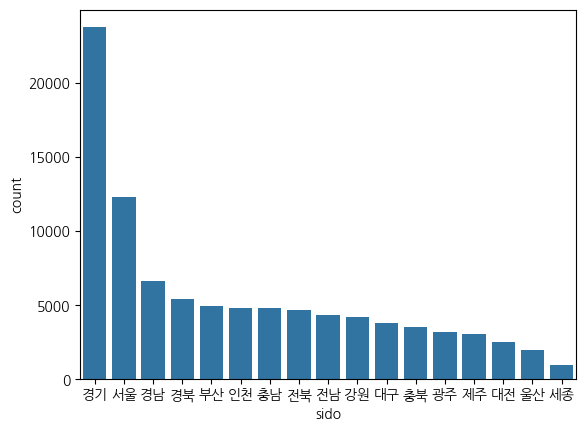

In [207]:
# 시각화 1: 지역(시도)별 전기차 충전소 개수 비교 (Bar Chart)
sns.countplot(data=df_short, x='sido', order=df_short['sido'].value_counts().index)

In [209]:
df_short['speed'].value_counts()

speed
완속    74135
급속    20812
기타      117
Name: count, dtype: int64

<Axes: ylabel='count'>

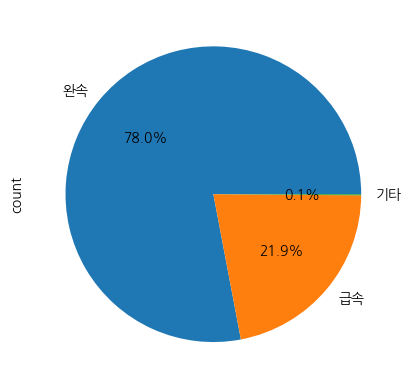

In [211]:
# 시각화 2: 충전기 타입(완속/급속 등) 비율 (Pie Chart)
df_short['speed'].value_counts().plot.pie(autopct='%1.1f%%')

<Axes: xlabel='sido', ylabel='count'>

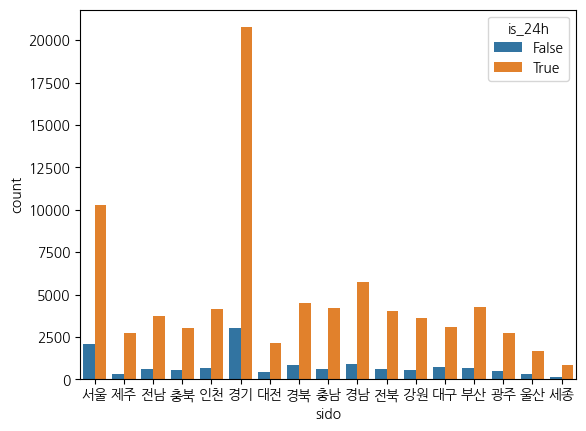

In [213]:
# 시각화 3: 지역별 24시간 개방 충전소 비율 (Stacked Bar Chart 또는 Countplot hue)
# Countplot hue 사용
sns.countplot(data=df_short, x='sido', hue='is_24h')

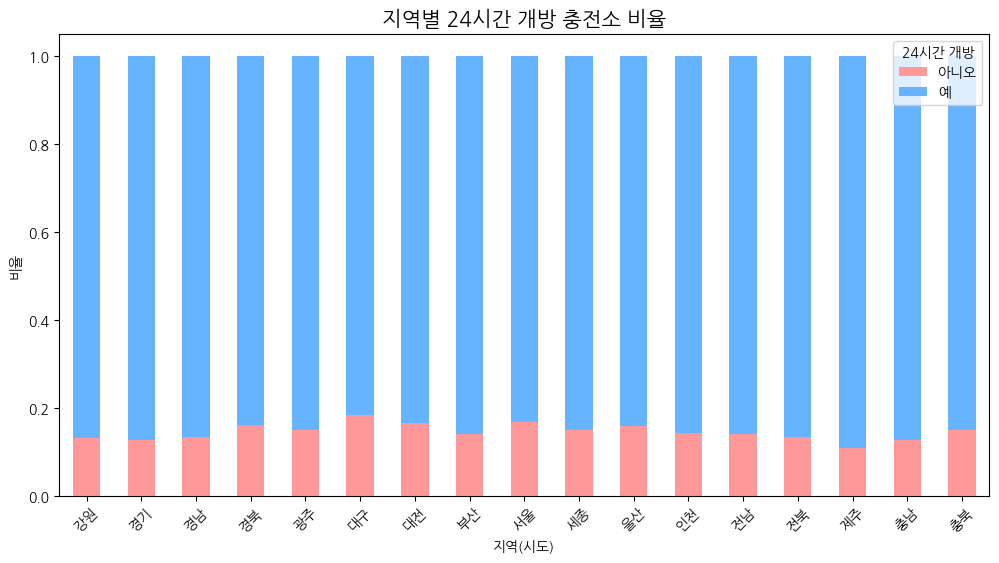

In [215]:
# Stacked Bar Chart 사용
# 1. 시도별 24시간 여부 교차표 생성
ct = pd.crosstab(df_short['sido'], df_short['is_24h'])

# 2. 비율로 변환 (각 행의 합으로 나눔) -> 0~1 사이 값
ct_pct = ct.div(ct.sum(1), axis=0)

# 3. 시각화
ax = ct_pct.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#ff9999', '#66b3ff'])

plt.title('지역별 24시간 개방 충전소 비율', fontsize=15)
plt.xlabel('지역(시도)')
plt.ylabel('비율')
plt.legend(title='24시간 개방', labels=['아니오', '예'], loc='upper right')
plt.xticks(rotation=45)
plt.show()

In [217]:
df_short['is_24h'].value_counts()

is_24h
True     81520
False    13544
Name: count, dtype: int64

<Axes: >

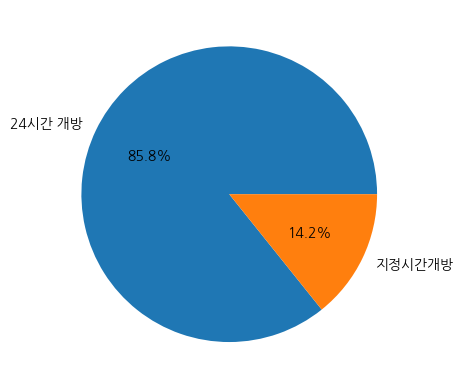

In [219]:
# 비율 확인
df_short['is_24h'].value_counts().rename({True: '24시간 개방', False: '지정시간개방'}).plot.pie(autopct='%1.1f%%', ylabel='')

## 도출 인사이트

In [ ]:
인프라 집중도 : 경기도, 서울 인프라 집중도가 높은편
기술 트랜드 : 완속이 78% 급속 22% 정도로 다소 기술 트랜드는 미흡해 보임
편의성 : 24시간개방이 85%이상으로 매우 편의성이 좋은것으로 보임